First, we try to visualize the depth and RGB images of img_0063 taken using the kv1 device

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

Matplotlib is building the font cache; this may take a moment.


In [ ]:
# define a helper function to display images
def display_image(image: np.ndarray,
                  title: str = "Image",
                  cmap: str | None = None) -> None:
    """
    Parameters
    ----------
    image : np.ndarray
        Image to display.

    title : str
        Figure title.

    cmap : str | None
        Colormap for grayscale images.
    """

    # ---------- Type checking ----------
    if image is None:
        raise ValueError("Image is None.")

    if not isinstance(image, np.ndarray):
        raise TypeError(
            f"Expected numpy.ndarray, got {type(image)}"
        )

    # ---------- Print useful information ----------
    print(f"Type : {type(image)}")
    print(f"Shape: {image.shape}")
    print(f"Dtype: {image.dtype}")

    # ---------- Plot ----------
    plt.figure(figsize=(8, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [ ]:
# always check your working directory before creating a path variable
print(Path.cwd())

In [ ]:
# HELPER: take a .png depth image and convert it to a depth matrix in meters
def load_depth(depth_path: Path) -> np.ndarray:
    """
    Load a depth image (.png)

    Returns
    -------
    depth : ndarray
        H × W float32 depth matrix (meters)
    """
    depth = cv2.imread(str(depth_path), cv2.IMREAD_UNCHANGED)

    if depth is None:
        raise FileNotFoundError(depth_path)

    # assumed decoding method. NEED VERIFICATION
    depth = depth.astype(np.uint16)
    depth = (depth >> 3) | (depth << 13)
    depth = depth.astype(np.float32) / 1000.0

    return depth

# HELPER: take a .jpg RGB image and convert it to a RGB matrix
def load_rgb(rgb_path: Path) -> np.ndarray:
    """
    Load an RGB image (.jpg)

    Returns
    -------
    rgb : ndarray
        H × W × 3 uint8 RGB image
    """
    rgb = cv2.imread(str(rgb_path), cv2.IMREAD_COLOR)

    if rgb is None:
        raise FileNotFoundError(rgb_path)

    # convert BGR to RGB
    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

    return rgb


def load_intrinsics(intrinsics_path: Path) -> np.ndarray:
    """
    Load a 3×3 camera intrinsic matrix.
    """
    return np.loadtxt(intrinsics_path)

In [ ]:
# build the path for the chosen image to visualize
DATA_ROOT = Path("../rawdata/SUNRGBD")
RGBimage_path = DATA_ROOT / "kv1" / "b3dodata" / "img_0063" / "image" / "img_0063.jpg"
Depthimage_path = DATA_ROOT / "kv1" / "b3dodata" / "img_0063" / "depth" / "img_0063_abs.png"

# read the images using OpenCV(cv2)
rgb = load_rgb(RGBimage_path)
depth = load_depth(Depthimage_path)


In [ ]:
# verfiy depth value range
print(depth.min(), depth.max())
print(depth[200:205, 300:305])

0.0 2.525
[[2.286 2.302 2.27  2.27  2.302]
 [2.27  2.27  2.27  2.27  2.27 ]
 [2.27  2.27  2.27  2.27  2.27 ]
 [2.27  2.27  2.255 2.27  2.255]
 [2.27  2.27  2.271 2.271 2.255]]


Type : <class 'numpy.ndarray'>
Shape: (427, 561, 3)
Dtype: uint8


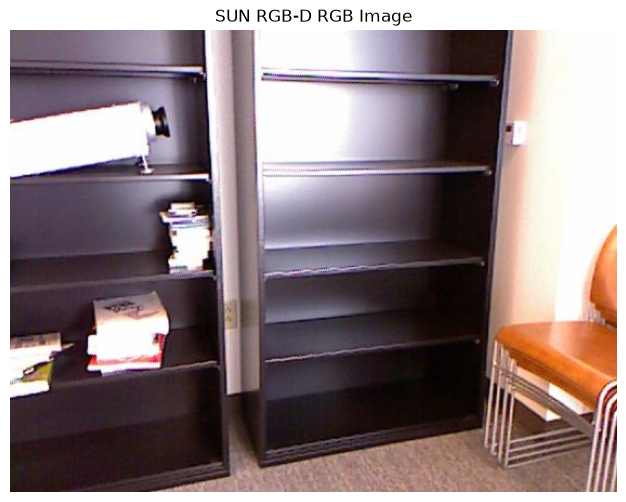

In [13]:
# Display RGB image
display_image(
    rgb,
    title="SUN RGB-D RGB Image"
)

Type : <class 'numpy.ndarray'>
Shape: (427, 561, 3)
Dtype: uint8


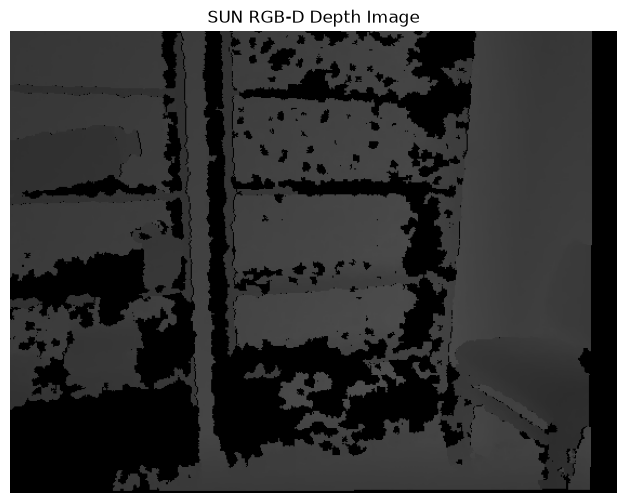

In [14]:
# Display Depth image
display_image(
    depth,
    title="SUN RGB-D Depth Image",
    cmap="gray"
)

In [ ]:
# HELPER: convert depth image to point cloud 3D coordinates
def depth_to_pointcloud_vectorized(depth, intrinsics):

    # use the provided sensor intrinsics 
    fx = intrinsics[0, 0]
    fy = intrinsics[1, 1]
    cx = intrinsics[0, 2]
    cy = intrinsics[1, 2]

    H, W = depth.shape

    u, v = np.meshgrid(np.arange(W), np.arange(H))

    # element-wise arithmetics to compute 3D coordinates
    Z = depth
    X = (u - cx) * Z / fx
    Y = (v - cy) * Z / fy

    # stack them into a single tensor of shape (H, W, 3)
    points = np.stack((X, Y, Z), axis=-1)

    valid = Z > 0 # depth value must be positive to be valid

    return points[valid]